# OmniSearch Detection Pipeline — Fire → Survivors

Sequential detection: **fire first, then survivors** (YOLOv8 person, class 0).

- Fire detector: HSV color thresholding + connected components — fast, runs every frame.
- Person detector: Ultralytics YOLOv8 with `classes=[0]` per the COCO class list (person = 0).
- Pipeline output: bounding boxes for both, plus a `survivors_in_fire` list (persons whose bbox overlaps or is near a fire region).

References:
- YOLOv8 predict mode & class filtering: https://docs.ultralytics.com/modes/predict
- COCO classes (person = 0): https://docs.ultralytics.com/datasets/detect/coco

## 1. Imports

In [1]:
import sys, os
sys.path.insert(0, '..')   # add repo root so we can import `detection`

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from ultralytics.utils import ASSETS

from detection import DetectionPipeline, FireDetector, PersonDetector

## 2. Visualisation helper

In [2]:
def show_detections(image, fire_dets, person_dets, in_fire=None, title=""):
    if not isinstance(image, np.ndarray):
        image = np.asarray(Image.open(image).convert('RGB')) if isinstance(image, str) else np.asarray(image)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(image)
    for f in fire_dets:
        x1, y1, x2, y2 = f.box
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2.5, edgecolor='orange', facecolor='none'))
        ax.text(x1, y1 - 6, f"FIRE {f.confidence:.2f}", color='orange',
                fontsize=9, fontweight='bold')
    in_fire_ids = set(id(p) for p in (in_fire or []))
    for p in person_dets:
        x1, y1, x2, y2 = p.box
        c = 'red' if id(p) in in_fire_ids else 'lime'
        label = 'SURVIVOR-IN-FIRE' if id(p) in in_fire_ids else 'person'
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2.0, edgecolor=c, facecolor='none'))
        ax.text(x1, y1 - 6, f"{label} {p.confidence:.2f}", color=c,
                fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 3. Build the pipeline

Default settings:
- Fire: HSV thresholds tuned for real flames (hue ≤ 30, value ≥ 200, saturation ≥ 180, min region 300 px)
- Person: `yolov8n.pt`, `classes=[0]`, conf ≥ 0.25

In [3]:
pipe = DetectionPipeline()
print("Pipeline ready — fire then person.")

Pipeline ready — fire then person.


## 4. Test 1 — Real photo with people, no fire

Ultralytics' built-in `bus.jpg`. Expect: ≥2 person boxes, 0 fire boxes, **no alert**.

fire detections: 0
person detections: 4
survivors_in_fire: 0
alert: False


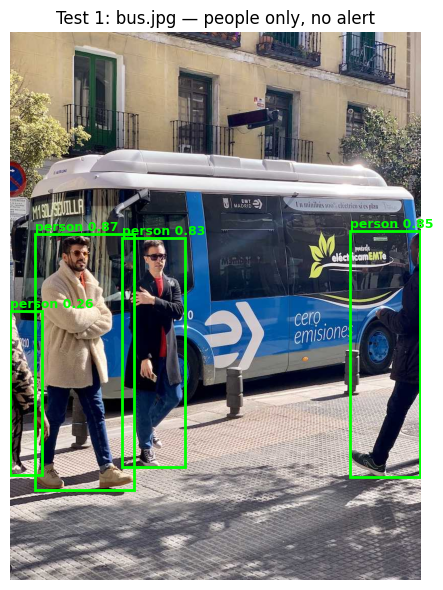

In [4]:
bus_path = str(ASSETS / 'bus.jpg')
r = pipe.run(bus_path)
print(f"fire detections: {len(r.fire.detections)}")
print(f"person detections: {r.persons.n_people}")
print(f"survivors_in_fire: {r.n_survivors_in_fire}")
print(f"alert: {r.alert}")
show_detections(bus_path, r.fire.detections, r.persons.detections, r.survivors_in_fire,
                title='Test 1: bus.jpg — people only, no alert')

## 5. Test 2 — Synthetic fire, no people

Pure orange-red blob. Expect: ≥1 fire box, 0 person boxes.

fire detections: 1
person detections: 0


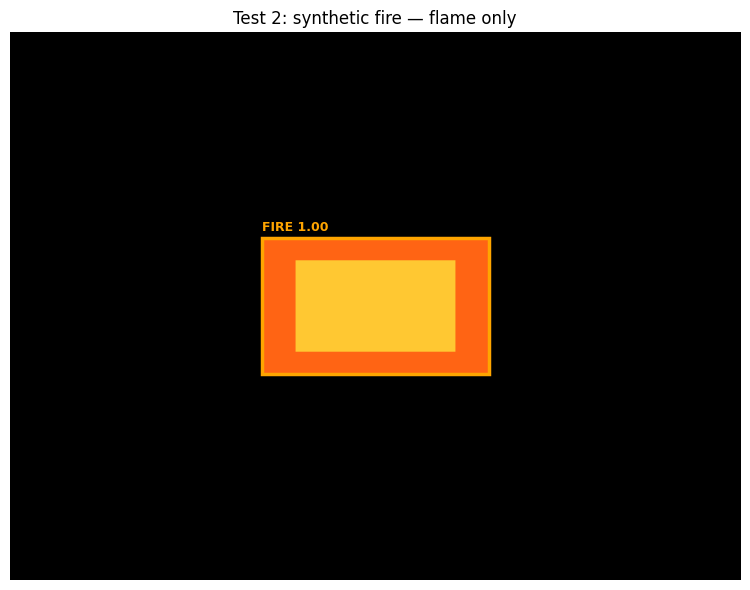

In [5]:
img = np.zeros((480, 640, 3), dtype=np.uint8)
img[180:300, 220:420] = [255, 100, 20]    # red-orange outer
img[200:280, 250:390] = [255, 200, 50]    # yellow core (flame-like)
synth = Image.fromarray(img)

r = pipe.run(synth)
print(f"fire detections: {len(r.fire.detections)}")
print(f"person detections: {r.persons.n_people}")
show_detections(img, r.fire.detections, r.persons.detections,
                title='Test 2: synthetic fire — flame only')

## 6. Test 3 — Composite: people on left, fire on right

Both detections should fire, but the **survivors-in-fire** count should be 0 — the geometry doesn't overlap. This validates that the proximity logic isn't just "any person + any fire => alert".

fire detections: 1
person detections: 3
survivors_in_fire: 0 (expect 0 — opposite sides)
alert: False


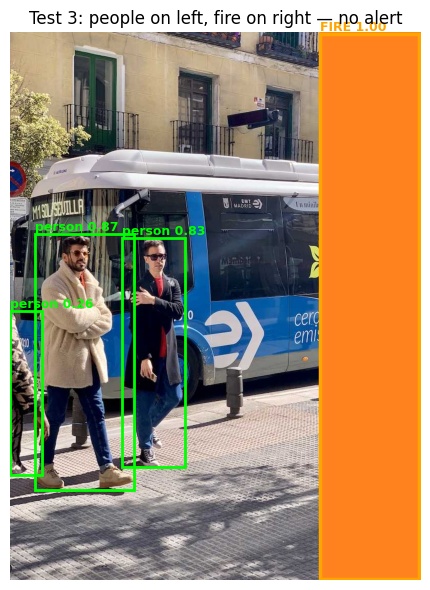

In [6]:
bus = Image.open(bus_path).convert('RGB')
bw, bh = bus.size
arr = np.array(Image.new('RGB', (bw, bh), (255, 130, 30)))     # orange canvas
arr[:, :bw - 200, :] = np.array(bus.crop((0, 0, bw - 200, bh))) # bus on the left
composite = Image.fromarray(arr)

r = pipe.run(composite)
print(f"fire detections: {len(r.fire.detections)}")
print(f"person detections: {r.persons.n_people}")
print(f"survivors_in_fire: {r.n_survivors_in_fire} (expect 0 — opposite sides)")
print(f"alert: {r.alert}")
show_detections(composite, r.fire.detections, r.persons.detections, r.survivors_in_fire,
                title='Test 3: people on left, fire on right — no alert')

## 7. Test 4 — Composite: person standing in fire

Now we put a person *inside* the fire region. Expect: **alert=True**, 1 survivor-in-fire.

fire detections: 1
person detections: 1
survivors_in_fire: 1
alert: True


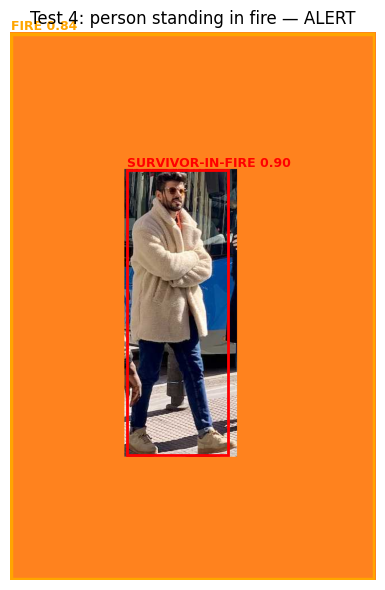

In [7]:
# Crop the leftmost person from bus.jpg and paste them onto a fire background
person_crop = bus.crop((48, 398, 245, 902))
fire_bg = Image.new('RGB', (640, 960), (255, 130, 30))
fire_bg.paste(person_crop, (200, 240))

r = pipe.run(fire_bg)
print(f"fire detections: {len(r.fire.detections)}")
print(f"person detections: {r.persons.n_people}")
print(f"survivors_in_fire: {r.n_survivors_in_fire}")
print(f"alert: {r.alert}")
show_detections(fire_bg, r.fire.detections, r.persons.detections, r.survivors_in_fire,
                title='Test 4: person standing in fire — ALERT')

## 8. Test 5 — Triggered mode (skip person detection if no fire)

In production, every frame from a UAV feed runs the cheap HSV fire detector. Only frames with fire are sent through the heavier YOLOv8. With `triggered_only=True`, the pipeline short-circuits on no-fire frames.

In [8]:
r = pipe.run(bus_path, triggered_only=True)
print(f"bus.jpg (no fire) with triggered_only=True:")
print(f"  fire={len(r.fire.detections)}  people={r.persons.n_people}  (YOLO skipped: 0 people)")

r = pipe.run(fire_bg, triggered_only=True)
print(f"\nfire_bg (has fire) with triggered_only=True:")
print(f"  fire={len(r.fire.detections)}  people={r.persons.n_people}  alert={r.alert}")

bus.jpg (no fire) with triggered_only=True:
  fire=0  people=0  (YOLO skipped: 0 people)



fire_bg (has fire) with triggered_only=True:
  fire=1  people=1  alert=True


## Next steps

1. **Real fire dataset**: swap the rule-based fire detector for a small CNN trained on fire imagery (e.g. FLAME, DFire) — the `FireDetector.detect` interface stays the same.
2. **Tuning**: thresholds were picked to avoid false positives on the bus photo; for production, sweep on a labeled dataset.
3. **Integration with VMAS**: when running rollouts of a trained MARL policy, render frames and run this pipeline on them for an end-to-end demo (sim → detection → operator alert).
4. **UAV video**: ``DetectionPipeline.run()`` accepts numpy arrays — drop it into a video loop for live processing.